In [6]:
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.preprocessing import image_dataset_from_directory
from tensorflow.keras.applications import MobileNetV3Large
from tensorflow.keras.applications.mobilenet_v3 import preprocess_input
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model

In [7]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42
AUTOTUNE = tf.data.AUTOTUNE

DATASET_DIR = "../DATASET/dataset_stage2"
TRAIN_DIR = os.path.join(DATASET_DIR, "train")
VAL_DIR = os.path.join(DATASET_DIR, "val")
TEST_DIR = os.path.join(DATASET_DIR, "test")

# Testing on real-life images (not used for training/validation)
REAL_LIFE_DIR = "../DATASET/dataset_stage2/real_world" 

# Training schedule
EPOCHS_PHASE1 = 5
EPOCHS_PHASE2 = 20
LR_PHASE1 = 1e-3
LR_PHASE2 = 1e-5

# Fine-tuning
N_UNFROZEN = 40  # unfreeze last N layers (BN stays frozen)

tf.random.set_seed(SEED)
np.random.seed(SEED)

In [ ]:
def _random_jpeg_quality(x, min_q=40, max_q=95):
    """Placeholder JPEG compression (no-op here for graph-mode safety)."""
    return x


def _gaussian_kernel(ksize: int, sigma: float):
    ax = tf.range(-ksize // 2 + 1, ksize // 2 + 1, dtype=tf.float32)
    xx, yy = tf.meshgrid(ax, ax)
    kernel = tf.exp(-(xx**2 + yy**2) / (2.0 * sigma**2))
    kernel = kernel / tf.reduce_sum(kernel)
    kernel = kernel[:, :, tf.newaxis, tf.newaxis]
    return kernel


def _gaussian_blur(x, ksize=5, sigma_min=0.3, sigma_max=1.5):
    sigma = tf.random.uniform([], sigma_min, sigma_max)
    kernel = _gaussian_kernel(ksize, sigma)
    x4 = x[tf.newaxis, ...]
    kernel = tf.tile(kernel, [1, 1, tf.shape(x)[-1], 1])  # (k,k,C,1)
    x_blur = tf.nn.depthwise_conv2d(x4, kernel, strides=[1, 1, 1, 1], padding="SAME")
    return x_blur[0]


def _add_sensor_noise(x, std_min=0.0, std_max=12.0):
    std = tf.random.uniform([], std_min, std_max)
    noise = tf.random.normal(tf.shape(x), mean=0.0, stddev=std, dtype=tf.float32)
    return tf.clip_by_value(x + noise, 0.0, 255.0)


def _random_crop_resize(x, y, min_scale=0.6, max_scale=1.0):
    h = tf.shape(x)[0]
    w = tf.shape(x)[1]
    scale = tf.random.uniform([], min_scale, max_scale)
    new_h = tf.maximum(tf.cast(tf.cast(h, tf.float32) * scale, tf.int32), 1)
    new_w = tf.maximum(tf.cast(tf.cast(w, tf.float32) * scale, tf.int32), 1)
    crop_size = tf.stack([new_h, new_w, tf.shape(x)[-1]])
    x = tf.image.random_crop(x, size=crop_size, seed=SEED)
    x = tf.image.resize(x, IMG_SIZE, method="bilinear")
    return x, y


# Small tilt augmentation using a Keras preprocessing layer
random_rotation = tf.keras.layers.RandomRotation(factor=20.0 / 360.0, fill_mode="reflect")


def _augment_single_example(x, y):
    """Augment a single image (unbatched)."""
    x, y = _random_crop_resize(x, y)

    # Horizontal flip
    x = tf.image.random_flip_left_right(x, seed=SEED)

    # Random 90° rotations sometimes
    do_rot90 = tf.random.uniform([]) < 0.20
    k = tf.random.uniform([], 0, 4, dtype=tf.int32)
    x = tf.cond(do_rot90, lambda: tf.image.rot90(x, k=k), lambda: x)

    # Small tilt using RandomRotation
    do_tilt = tf.random.uniform([]) < 0.60
    x = tf.cond(
        do_tilt,
        lambda: random_rotation(x[tf.newaxis, ...], training=True)[0],
        lambda: x,
    )

    # Color / lighting tweaks
    x = tf.image.random_brightness(x, max_delta=0.25)
    x = tf.image.random_contrast(x, lower=0.6, upper=1.4)
    x = tf.image.random_saturation(x, lower=0.7, upper=1.3)
    x = tf.image.random_hue(x, max_delta=0.05)

    # Occasional blur / sensor noise
    x = tf.cond(tf.random.uniform([]) < 0.35, lambda: _gaussian_blur(x, ksize=5), lambda: x)
    x = tf.cond(tf.random.uniform([]) < 0.50, lambda: _add_sensor_noise(x), lambda: x)

    # Model preprocessing
    x = preprocess_input(x)
    return x, y


def camera_like_augment(x, y):
    """Apply augmentations to batched or single images."""
    # image_dataset_from_directory yields batched tensors (B,H,W,C)
    if x.shape.rank == 4:
        x, y = tf.map_fn(
            lambda sample: _augment_single_example(sample[0], sample[1]),
            (x, y),
            fn_output_signature=(tf.float32, tf.float32),
        )
        return x, y

    return _augment_single_example(x, y)


def basic_preprocess(x, y):
    return preprocess_input(x), y

In [ ]:
def camera_like_augment(x, y):
    """Apply augmentations to batched or single images."""
    if x.shape.rank == 4:
        x, y = tf.map_fn(
            lambda sample: _camera_like_augment_single(sample[0], sample[1]),
            (x, y),
            fn_output_signature=(tf.float32, tf.float32),
        )
        return x, y
    
    return _camera_like_augment_single(x, y)


def _camera_like_augment_single(x, y):
    """Augment a single image; input is float32 in [0,255]."""
    x, y = _random_crop_resize(x, y)

    # Flip and orientation
    x = tf.image.random_flip_left_right(x, seed=SEED)
    do_rot90 = tf.random.uniform([]) < 0.20
    k = tf.random.uniform([], 0, 4, dtype=tf.int32)
    x = tf.cond(do_rot90, lambda: tf.image.rot90(x, k=k), lambda: x)

    # Tilt (small rotation)
    do_tilt = tf.random.uniform([]) < 0.60
    x = tf.cond(
        do_tilt,
        lambda: random_rotation(x[tf.newaxis, ...], training=True)[0],
        lambda: x,
    )

    # Color / lighting
    x = tf.image.random_brightness(x, max_delta=0.25)
    x = tf.image.random_contrast(x, lower=0.6, upper=1.4)
    x = tf.image.random_saturation(x, lower=0.7, upper=1.3)
    x = tf.image.random_hue(x, max_delta=0.05)

    # Blur / noise / jpeg
    x = tf.cond(tf.random.uniform([]) < 0.35, lambda: _gaussian_blur(x, ksize=5), lambda: x)
    x = tf.cond(tf.random.uniform([]) < 0.50, lambda: _add_sensor_noise(x), lambda: x)
    x = tf.cond(tf.random.uniform([]) < 0.35, lambda: _random_jpeg_quality(x), lambda: x)

    # Final model preprocessing
    x = preprocess_input(x)
    return x, y


def basic_preprocess(x, y):
    return preprocess_input(x), y

In [10]:
train_ds = image_dataset_from_directory(
    TRAIN_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=True,
    seed=SEED
)

val_ds = image_dataset_from_directory(
    VAL_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=False
)

test_ds = image_dataset_from_directory(
    TEST_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=False
)

class_names = train_ds.class_names
NUM_CLASSES = len(class_names)
print("Class names:", class_names)
print("NUM_CLASSES:", NUM_CLASSES)

real_life_ds = None
if REAL_LIFE_DIR is not None and os.path.isdir(REAL_LIFE_DIR):
    real_life_ds = image_dataset_from_directory(
        REAL_LIFE_DIR,
        image_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        label_mode="categorical",
        shuffle=False
    )
    print("Real-life class names:", real_life_ds.class_names)
else:
    print("Real-life class names: N/A (REAL_LIFE_DIR not found)")

train_ds = train_ds.map(camera_like_augment, num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)
val_ds = val_ds.map(basic_preprocess, num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)
test_ds = test_ds.map(basic_preprocess, num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)

if real_life_ds is not None:
    real_life_ds = real_life_ds.map(basic_preprocess, num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)

Found 4000 files belonging to 5 classes.
Found 480 files belonging to 5 classes.
Found 501 files belonging to 5 classes.
Class names: ['glass', 'metal', 'paper', 'plastic', 'residual']
NUM_CLASSES: 5
Found 340 files belonging to 5 classes.
Real-life class names: ['glass', 'metal', 'paper', 'plastic', 'residual']


In [11]:
base_model = MobileNetV3Large(
    input_shape=IMG_SIZE + (3,),
    include_top=False,
    weights="imagenet"
)

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation="relu")(x)
x = Dropout(0.5)(x)
output = Dense(NUM_CLASSES, activation="softmax")(x)

model = Model(inputs=base_model.input, outputs=output)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv (Conv2D)       │ (None, 112, 112,  │        432 │ rescaling[0][0]   │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_bn             │ (None, 112, 112,  │         64 │ conv[0][0]        │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 112, 112,  │          0 │ conv_bn[0][0]     │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        144 │ activation[0][0]  │
│ (DepthwiseConv2D)   │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │         64 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        256 │ re_lu[0][0]       │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_add   │ (None, 112, 112,  │          0 │ activation[0][0], │
│ (Add)               │ 16)               │            │ expanded_conv_pr… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_1_ex… │ (None, 112, 112,  │      1,024 │ expanded_conv_ad… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_1_ex… │ (None, 112, 112,  │        256 │ expanded_conv_1_… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_1 (ReLU)      │ (None, 112, 112,  │          0 │ expanded_conv_1_… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_1_de… │ (None, 113, 113,  │          0 │ re_lu_1[0][0]     │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_1_de… │ (None, 56, 56,    │        576 │ expanded_conv_1_… │
│ (DepthwiseConv2D)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_1_de… │ (None, 56, 56,    │        256 │ expanded_conv_1_

 Total params: 3,243,653 (12.37 MB)

 Trainable params: 3,219,253 (12.28 MB)

 Non-trainable params: 24,400 (95.31 KB)

In [12]:
def compile_model(lr: float):
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.05),
        metrics=[
            "accuracy",
            tf.keras.metrics.TopKCategoricalAccuracy(k=2, name="top2_acc"),
            tf.keras.metrics.TopKCategoricalAccuracy(k=3, name="top3_acc"),

            # One-vs-rest PR-AUC over classes (macro-ish behavior)
            tf.keras.metrics.AUC(name="pr_auc_ovr", curve="PR", multi_label=True, num_labels=NUM_CLASSES),
        ],
    )

In [13]:
import numpy as np
from sklearn.metrics import precision_score, recall_score

class MacroPRCallback(tf.keras.callbacks.Callback):
    def __init__(self, val_ds, num_classes, name_prefix=""):
        super().__init__()
        self.val_ds = val_ds
        self.num_classes = num_classes
        self.name_prefix = name_prefix

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}

        y_true = []
        y_prob = []
        for xb, yb in self.val_ds:
            p = self.model.predict(xb, verbose=0)
            y_prob.append(p)
            y_true.append(np.argmax(yb.numpy(), axis=1))

        y_true = np.concatenate(y_true)
        y_prob = np.concatenate(y_prob, axis=0)
        y_pred = np.argmax(y_prob, axis=1)

        macro_prec = precision_score(y_true, y_pred, average="macro", zero_division=0)
        macro_rec = recall_score(y_true, y_pred, average="macro", zero_division=0)

        logs["precision"] = macro_prec
        logs["recall"] = macro_rec
        # Keras will automatically prefix val_? No—so we store them as val_precision/val_recall:
        logs["val_precision"] = macro_prec
        logs["val_recall"] = macro_rec

        print(f"\n[macro] val_precision={macro_prec:.4f} val_recall={macro_rec:.4f}")

macro_cb = MacroPRCallback(val_ds=val_ds, num_classes=NUM_CLASSES)

In [14]:
base_model.trainable = False
compile_model(LR_PHASE1)

callbacks_phase1 = [
    tf.keras.callbacks.EarlyStopping(monitor="val_pr_auc_ovr", mode="max", patience=3, restore_best_weights=True),
    macro_cb,
]

history1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_PHASE1,
    callbacks=callbacks_phase1
)

Epoch 1/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 700ms/step - accuracy: 0.5702 - loss: 1.2549 - pr_auc_ovr: 0.6306 - top2_acc: 0.7595 - top3_acc: 0.8772
[macro] val_precision=0.7858 val_recall=0.7725
125/125 ━━━━━━━━━━━━━━━━━━━━ 132s 970ms/step - accuracy: 0.6877 - loss: 0.9715 - pr_auc_ovr: 0.7714 - top2_acc: 0.8457 - top3_acc: 0.9302 - val_accuracy: 0.7729 - val_loss: 0.7912 - val_pr_auc_ovr: 0.8693 - val_top2_acc: 0.8896 - val_top3_acc: 0.9438 - precision: 0.7858 - recall: 0.7725 - val_precision: 0.7858 - val_recall: 0.7725
Epoch 2/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 601ms/step - accuracy: 0.8057 - loss: 0.6978 - pr_auc_ovr: 0.8910 - top2_acc: 0.9308 - top3_acc: 0.9748
[macro] val_precision=0.8311 val_recall=0.8275
125/125 ━━━━━━━━━━━━━━━━━━━━ 94s 751ms/step - accuracy: 0.8155 - loss: 0.6834 - pr_auc_ovr: 0.8988 - top2_acc: 0.9320 - top3_acc: 0.9760 - val_accuracy: 0.8292 - val_loss: 0.6648 - val_pr_auc_ovr: 0.9048 - val_top2_acc: 0.9229 - val_top3_acc: 0.9646 - precision: 0.8311 - recall: 0

In [15]:
base_model.trainable = True

for layer in base_model.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

for layer in base_model.layers[:-N_UNFROZEN]:
    layer.trainable = False

compile_model(LR_PHASE2)

callbacks_phase2 = [
    tf.keras.callbacks.EarlyStopping(monitor="val_pr_auc_ovr", mode="max", patience=5, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor="val_pr_auc_ovr", mode="max", factor=0.5, patience=2, min_lr=1e-7),
    macro_cb,
]

history2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_PHASE2,
    callbacks=callbacks_phase2
)

Epoch 1/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 740ms/step - accuracy: 0.8970 - loss: 0.5203 - pr_auc_ovr: 0.9574 - top2_acc: 0.9677 - top3_acc: 0.9914
[macro] val_precision=0.8608 val_recall=0.8545
125/125 ━━━━━━━━━━━━━━━━━━━━ 127s 909ms/step - accuracy: 0.9025 - loss: 0.5075 - pr_auc_ovr: 0.9626 - top2_acc: 0.9715 - top3_acc: 0.9905 - val_accuracy: 0.8562 - val_loss: 0.5819 - val_pr_auc_ovr: 0.9430 - val_top2_acc: 0.9417 - val_top3_acc: 0.9812 - learning_rate: 1.0000e-05 - precision: 0.8608 - recall: 0.8545 - val_precision: 0.8608 - val_recall: 0.8545
Epoch 2/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 730ms/step - accuracy: 0.9013 - loss: 0.4992 - pr_auc_ovr: 0.9629 - top2_acc: 0.9762 - top3_acc: 0.9911
[macro] val_precision=0.8670 val_recall=0.8605
125/125 ━━━━━━━━━━━━━━━━━━━━ 137s 869ms/step - accuracy: 0.9062 - loss: 0.4960 - pr_auc_ovr: 0.9646 - top2_acc: 0.9732 - top3_acc: 0.9902 - val_accuracy: 0.8625 - val_loss: 0.5737 - val_pr_auc_ovr: 0.9444 - val_top2_acc: 0.9438 - val_top3_acc: 0.9812 

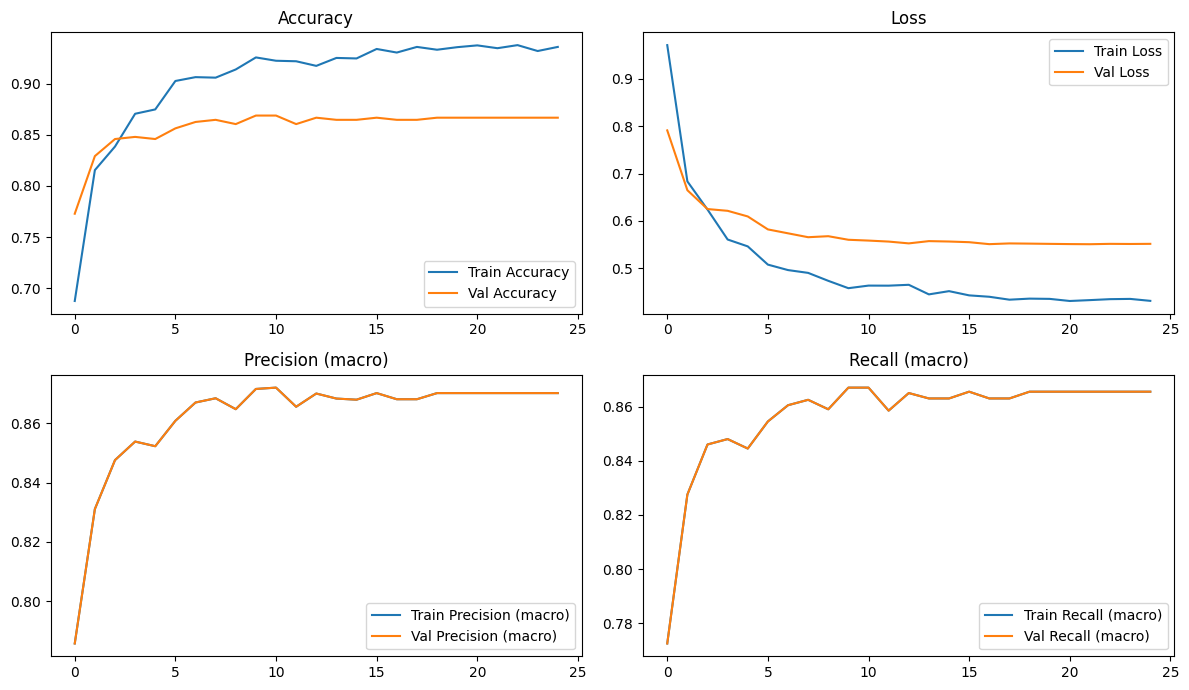

In [16]:
def merge_histories(h1, h2):
    merged = {}
    keys = set(h1.history.keys()) | set(h2.history.keys())
    for k in keys:
        merged[k] = list(h1.history.get(k, [])) + list(h2.history.get(k, []))
    return merged

merged = merge_histories(history1, history2)

plt.figure(figsize=(12, 7))

plt.subplot(2, 2, 1)
plt.plot(merged.get("accuracy", []), label="Train Accuracy")
plt.plot(merged.get("val_accuracy", []), label="Val Accuracy")
plt.legend(); plt.title("Accuracy")

plt.subplot(2, 2, 2)
plt.plot(merged.get("loss", []), label="Train Loss")
plt.plot(merged.get("val_loss", []), label="Val Loss")
plt.legend(); plt.title("Loss")

plt.subplot(2, 2, 3)
plt.plot(merged.get("precision", []), label="Train Precision (macro)")
plt.plot(merged.get("val_precision", []), label="Val Precision (macro)")
plt.legend(); plt.title("Precision (macro)")

plt.subplot(2, 2, 4)
plt.plot(merged.get("recall", []), label="Train Recall (macro)")
plt.plot(merged.get("val_recall", []), label="Val Recall (macro)")
plt.legend(); plt.title("Recall (macro)")

plt.tight_layout()
plt.show()


TEST
              precision    recall  f1-score   support

       glass     0.9368    0.8900    0.9128       100
       metal     0.9406    0.9500    0.9453       100
       paper     0.9100    0.9100    0.9100       100
     plastic     0.8785    0.9400    0.9082       100
    residual     0.9388    0.9109    0.9246       101

    accuracy                         0.9202       501
   macro avg     0.9209    0.9202    0.9202       501
weighted avg     0.9210    0.9202    0.9202       501



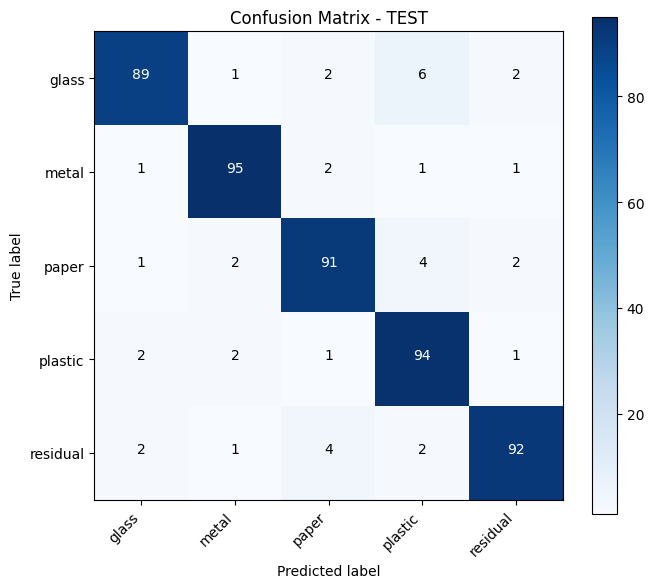


REAL-LIFE
              precision    recall  f1-score   support

       glass     0.7273    0.4800    0.5783        50
       metal     0.5694    0.8200    0.6721        50
       paper     0.8395    0.9067    0.8718        75
     plastic     0.8148    0.8381    0.8263       105
    residual     0.7826    0.6000    0.6792        60

    accuracy                         0.7559       340
   macro avg     0.7467    0.7290    0.7256       340
weighted avg     0.7656    0.7559    0.7512       340



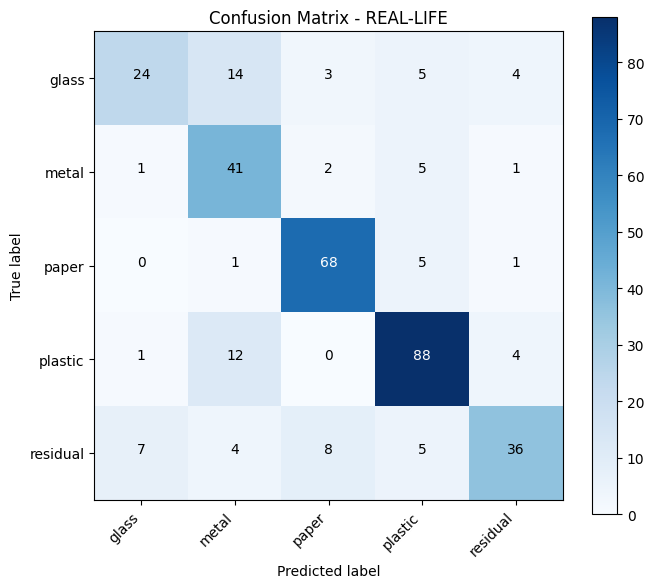

In [17]:
def report_and_cm_multiclass(ds, class_names, title=""):
    y_true = []
    y_probs = []

    for xb, yb in ds:
        probs = model.predict(xb, verbose=0)
        y_probs.append(probs)
        y_true.append(np.argmax(yb.numpy(), axis=1))

    y_probs = np.concatenate(y_probs, axis=0)
    y_true = np.concatenate(y_true, axis=0)
    y_pred = np.argmax(y_probs, axis=1)

    print("\n" + title)
    print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(7, 6))
    plt.imshow(cm, interpolation="nearest", cmap=plt.cm.Blues)
    plt.title(f"Confusion Matrix - {title}")
    plt.colorbar()
    tick_marks = np.arange(len(class_names))
    plt.xticks(tick_marks, class_names, rotation=45, ha="right")
    plt.yticks(tick_marks, class_names)

    thresh = cm.max() / 2 if cm.max() > 0 else 0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, cm[i, j],
                     horizontalalignment="center",
                     color="white" if cm[i, j] > thresh else "black")

    plt.ylabel("True label")
    plt.xlabel("Predicted label")
    plt.tight_layout()
    plt.show()

# TEST confusion matrix
report_and_cm_multiclass(test_ds, class_names, title="TEST")

# REAL-LIFE confusion matrix (if you have it)
if real_life_ds is not None:
    report_and_cm_multiclass(real_life_ds, class_names, title="REAL-LIFE")

In [18]:
print("\nDataset test evaluation:")
model.evaluate(test_ds, verbose=2)

if real_life_ds is not None:
    print("\nReal-life evaluation:")
    model.evaluate(real_life_ds, verbose=2)


Dataset test evaluation:
16/16 - 9s - 582ms/step - accuracy: 0.9202 - loss: 0.4438 - pr_auc_ovr: 0.9778 - top2_acc: 0.9820 - top3_acc: 0.9980

Real-life evaluation:
11/11 - 11s - 1s/step - accuracy: 0.7559 - loss: 0.7736 - pr_auc_ovr: 0.8516 - top2_acc: 0.8794 - top3_acc: 0.9471


In [19]:
def collect_probs_and_labels(ds):
    y_true = []
    y_prob = []
    for xb, yb in ds:
        p = model.predict(xb, verbose=0)  # (B, C)
        y_prob.append(p)
        y_true.append(yb.numpy())
    y_true = np.concatenate(y_true, axis=0)  # one-hot
    y_prob = np.concatenate(y_prob, axis=0)
    y_true_idx = np.argmax(y_true, axis=1)
    return y_true, y_true_idx, y_prob

cal_ds = real_life_ds if real_life_ds is not None else test_ds  # fallback, but real-life is strongly preferred
y_true_oh, y_true_idx, y_prob = collect_probs_and_labels(cal_ds)

print("Calibration dataset size:", len(y_true_idx))

Calibration dataset size: 340


In [ ]:
def calibrate_uncertainty_thresholds(
    y_true_idx,
    y_prob,
    num_classes,
    t_grid=np.linspace(0.40, 0.90, 11),
    margin_grid=np.linspace(0.00, 0.30, 7),
    min_recall_per_class=0.70,   # increase as you collect more real-life images
):
    # Per-class threshold uses same t for all classes initially
    best = None

    p_sorted = np.sort(y_prob, axis=1)
    p1 = p_sorted[:, -1]
    p2 = p_sorted[:, -2]
    pred = np.argmax(y_prob, axis=1)

    for t in t_grid:
        for m in margin_grid:
            accept = (p1 >= t) & ((p1 - p2) >= m)
            coverage = float(np.mean(accept))

            # compute per-class recall among samples of that true class:
            ok = True
            recalls = []
            for c in range(num_classes):
                mask = (y_true_idx == c)
                if not np.any(mask):
                    # no samples of this class in calibration set -> can't constrain it
                    recalls.append(np.nan)
                    continue
                recall_c = float(np.mean((pred[mask] == c) & accept[mask]))
                recalls.append(recall_c)
                if recall_c < min_recall_per_class:
                    ok = False
                    break
            if not ok:
                continue

            candidate = {"t": float(t), "margin": float(m), "coverage": coverage, "recalls": recalls}
            if best is None or candidate["coverage"] > best["coverage"]:
                best = candidate

    return best

best_u = calibrate_uncertainty_thresholds(
    y_true_idx=y_true_idx,
    y_prob=y_prob,
    num_classes=NUM_CLASSES,
    min_recall_per_class=0.70
)

if best_u is None:
    print("No thresholds met constraints. Relax min_recall_per_class (e.g., 0.6) or collect more real-life images.")
else:
    print("Chosen uncertainty params:")
    print("  accept if max_prob >= t AND (p1 - p2) >= margin")
    print(f"  t = {best_u['t']:.2f}")
    print(f"  margin = {best_u['margin']:.2f}")
    print(f"  coverage = {best_u['coverage']:.3f}")
    for i, r in enumerate(best_u["recalls"]):
        print(f"  recall[{class_names[i]}] = {r}")

No thresholds met constraints. Relax min_recall_per_class (e.g., 0.6) or collect more real-life images.


In [21]:
def apply_uncertainty_policy(y_prob, t, margin):
    p_sorted = np.sort(y_prob, axis=1)
    p1 = p_sorted[:, -1]
    p2 = p_sorted[:, -2]
    pred = np.argmax(y_prob, axis=1)
    accept = (p1 >= t) & ((p1 - p2) >= margin)
    pred_or_uncertain = pred.copy()
    pred_or_uncertain[~accept] = -1
    return pred_or_uncertain, accept

if best_u is not None:
    pred_u, accept = apply_uncertainty_policy(y_prob, best_u["t"], best_u["margin"])
    print("Uncertain rate:", float(np.mean(~accept)))

    # confusion matrix on accepted only
    accepted_idx = np.where(accept)[0]
    if len(accepted_idx) > 0:
        y_true_acc = y_true_idx[accepted_idx]
        y_pred_acc = pred_u[accepted_idx]

        cm = tf.math.confusion_matrix(y_true_acc, y_pred_acc, num_classes=NUM_CLASSES).numpy()
        print("Confusion matrix (accepted samples only):")
        print(cm)
    else:
        print("No accepted samples under current thresholds.")

In [22]:
OUT_DIR = "./enhanced-model"
os.makedirs(OUT_DIR, exist_ok=True)

tflite_path = os.path.join(OUT_DIR, "stage2_model.tflite")
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()
with open(tflite_path, "wb") as f:
    f.write(tflite_model)
print("Saved TFLite model to:", tflite_path)

if best_u is not None:
    np.savez(
        os.path.join(OUT_DIR, "stage2_uncertainty_params.npz"),
        t=best_u["t"],
        margin=best_u["margin"],
        class_names=np.array(class_names, dtype=object),
    )
    print("Saved uncertainty params.")

INFO:tensorflow:Assets written to: C:\Users\VIRGIL~1\AppData\Local\Temp\tmpodhlqk9b\assets


INFO:tensorflow:Assets written to: C:\Users\VIRGIL~1\AppData\Local\Temp\tmpodhlqk9b\assets


Saved artifact at 'C:\Users\VIRGIL~1\AppData\Local\Temp\tmpodhlqk9b'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 5), dtype=tf.float32, name=None)
Captures:
  1991501854000: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1991502680960: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1991502689232: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1991502686592: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1991502678144: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1991502690464: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1991502683952: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1991502684480: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1991502685536: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1991502253568: TensorSpec(shape=(), dtype=tf.resource, name=None)
  19